# `expansion_hunter_03_budget` — pilot, cost, keep list

Run **in a VWB JupyterLab app** after a one-sample smoke in
[`expansion_hunter_02_run_batch.ipynb`](expansion_hunter_02_run_batch.ipynb).

This notebook does **not** replace `_02`. `_02` stays the one-sample smoke.
Here we:

1. Draw a random **pilot** (20 samples) from the v9 CRAM manifest (or a CSV)
2. Submit **minicram then genotype** on native Google Batch (flags off until you flip them)
3. Estimate **p90 / p95** cost from VM wall time + Nearline `data_transfer_stats`
4. Write `keep.csv` under the run ledger so
   [`expansion_hunter_04_dispatch.ipynb`](expansion_hunter_04_dispatch.ipynb)
   can run the rest of the cohort under `BUDGET_USD`

Shared ledger: `scripts/vwb_batch/`. Sample outputs stay at
`gs://…/batchRuns/expansion_hunter/{sample_id}/`. Run metadata lives at
`gs://…/batchRuns/expansion_hunter/runs/{RUN_ID}/`.

Production catalog is the 711-locus degenerate panel. One-sample smoke on
`1000000` already SUCCEEDED (`eh-mini-260929-051752` ~8 min / 67.5 MiB,
`eh-gt-260929-053643` ~1 min). Batch has **no DAG**: this notebook polls
minicram, then you flip genotype. Success = Batch SUCCEEDED **and** GCS
objects exist. `SUBMIT_*` stay **off** until you turn one on.


In [25]:
from __future__ import annotations

import json
import os
import random
import shutil
import sys
from datetime import datetime, timezone
from pathlib import Path


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "scripts" / "vwb_batch" / "dispatch.py").is_file():
            return p
        nested = p / "aou-lr-phase-2" / "scripts" / "vwb_batch" / "dispatch.py"
        if nested.is_file():
            return nested.parents[2]
    raise FileNotFoundError("Cannot find scripts/vwb_batch. Clone kvg/aou-lr-phase-2 and re-run.")


REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT / "scripts"))

from vwb_batch import alloc, cohort, cost, dispatch, gcs, poll, registry, submit  # noqa: E402
from vwb_batch.pipelines import expansion_hunter as eh  # noqa: E402

SCRATCH = Path.cwd() / "expansion_hunter_rw_scratch"
SCRATCH.mkdir(parents=True, exist_ok=True)

OUTPUT_BUCKET_GS = os.environ.get("EH_OUTPUT_BUCKET_GS", "gs://aou-lr-phase2-resources/")
REGION = os.environ.get("DSUB_REGION", "us-central1")
REF_FA = os.environ.get(
    "EH_REF_FA",
    "gs://aou-lr-phase2-resources/locityper/refs/Homo_sapiens_assembly38.fasta",
)
REF_FAI = os.environ.get(
    "EH_REF_FAI",
    "gs://aou-lr-phase2-resources/locityper/refs/Homo_sapiens_assembly38.fasta.fai",
)
CATALOG_KIND = "degenerate"
DEG_CATALOG_LOCAL = REPO_ROOT / "expansion_hunter" / "configs" / "candidate_EH_Loci.GRCh38.degenerate.json"
CATALOG = os.environ.get(
    "EH_CATALOG",
    f"{OUTPUT_BUCKET_GS.rstrip('/')}/expansion_hunter/candidate_EH_Loci.GRCh38.degenerate.json",
)
STAGE_CATALOG = True

PRINT_READS_DOCKER = os.environ.get(
    "EH_PRINT_READS_DOCKER",
    "us-central1-docker.pkg.dev/broad-dsp-lrma/aou-lr/aou-locityper-print-reads:0.1.2",
)
EH_DOCKER = os.environ.get(
    "EH_DOCKER",
    "us-central1-docker.pkg.dev/broad-dsp-lrma/aou-lr/aou-expansion-hunter:0.1.0",
)

OUT_PREFIX = os.environ.get(
    "EH_BATCH_OUT_PREFIX",
    f"{OUTPUT_BUCKET_GS.rstrip('/')}/batchRuns/expansion_hunter",
)
RUN_ID = os.environ.get("EH_RUN_ID") or f"eh-{datetime.now(timezone.utc).strftime('%y%m%d')}-pilot"  # pin this for dispatch
COHORT_CSV = os.environ.get("EH_COHORT_CSV", "")
PILOT_N = int(os.environ.get("EH_PILOT_N", "20"))
PILOT_SEED = int(os.environ.get("EH_PILOT_SEED", "1"))
SHARD_SIZE = int(os.environ.get("EH_SHARD_SIZE", "100"))
PARALLELISM = int(os.environ.get("EH_PILOT_PARALLELISM", "20"))
MAX_RUN_DURATION = os.environ.get("EH_MAX_RUN_DURATION", "28800s")
DEFAULT_SEX = "female"

SUBMIT_PILOT_MINICRAM = False
SUBMIT_PILOT_GENOTYPE = True
WRITE_KEEP = True
WRITE_COMPUTE = True
BUDGET_USD = float(os.environ.get("EH_BUDGET_USD", "100") or 100)
RETRY_MARGIN = float(os.environ.get("EH_RETRY_MARGIN", "1.15"))
COST_QUANTILE = float(os.environ.get("EH_COST_QUANTILE", "0.90"))

PATHS = registry.run_paths(
    output_bucket=OUTPUT_BUCKET_GS.rstrip("/"),
    pipeline="expansion_hunter",
    run_id=RUN_ID,
)

print("REPO_ROOT:", REPO_ROOT)
print("RUN_ID:", RUN_ID)
print("ledger:", PATHS.prefix)
print("OUT_PREFIX:", OUT_PREFIX)
print("CATALOG:", CATALOG)
print("PILOT_N:", PILOT_N, "SEED:", PILOT_SEED)
print("PARALLELISM:", PARALLELISM, "SHARD_SIZE:", SHARD_SIZE)
print("BUDGET_USD:", BUDGET_USD, "quantile:", COST_QUANTILE, "margin:", RETRY_MARGIN)
print("SUBMIT_PILOT_MINICRAM:", SUBMIT_PILOT_MINICRAM, "SUBMIT_PILOT_GENOTYPE:", SUBMIT_PILOT_GENOTYPE)
print("WRITE_KEEP:", WRITE_KEEP, "WRITE_COMPUTE:", WRITE_COMPUTE)
print("PET_SA_EMAIL:", os.environ.get("PET_SA_EMAIL", "(unset)"))
print("gcloud:", shutil.which("gcloud"))


REPO_ROOT: /home/jupyter/repos/aou-lr-phase-2
RUN_ID: eh-260929-pilot
ledger: gs://aou-lr-phase2-resources/batchRuns/expansion_hunter/runs/eh-260929-pilot
OUT_PREFIX: gs://aou-lr-phase2-resources/batchRuns/expansion_hunter
CATALOG: gs://aou-lr-phase2-resources/expansion_hunter/candidate_EH_Loci.GRCh38.degenerate.json
PILOT_N: 20 SEED: 1
PARALLELISM: 20 SHARD_SIZE: 100
BUDGET_USD: 100.0 quantile: 0.9 margin: 1.15
SUBMIT_PILOT_MINICRAM: False SUBMIT_PILOT_GENOTYPE: True
WRITE_KEEP: True WRITE_COMPUTE: True
PET_SA_EMAIL: pet-2759429535691cc9a0dcb@wb-steady-asparagus-6800.iam.gserviceaccount.com
gcloud: /usr/bin/gcloud


## PET SA / VPC

Jobs run as `PET_SA_EMAIL` on the workspace private VPC. No dsub. PET cannot
read Cloud Logging; use `{sample}.minicram.worker.log` / `{sample}.EH.worker.log`.


In [2]:
if shutil.which("gcloud") is None:
    raise SystemExit("gcloud is not on PATH. Open this notebook in a VWB Jupyter app.")
project, sa = alloc.require_vwb_env()
if not DEG_CATALOG_LOCAL.is_file():
    raise SystemExit(f"missing catalog: {DEG_CATALOG_LOCAL}")
print("project:", project)
print("PET_SA_EMAIL:", sa)
print("region:", REGION)
print("network: projects/{}/global/networks/network".format(project))


project: wb-steady-asparagus-6800
PET_SA_EMAIL: pet-2759429535691cc9a0dcb@wb-steady-asparagus-6800.iam.gserviceaccount.com
region: us-central1
network: projects/wb-steady-asparagus-6800/global/networks/network


## Stage catalog

Copies the degenerate JSON to GCS if it is missing. Does not submit Batch.


In [3]:
if STAGE_CATALOG and not gcs.exists(CATALOG):
    print("uploading", DEG_CATALOG_LOCAL, "->", CATALOG)
    gcs.upload_file(DEG_CATALOG_LOCAL, CATALOG)
else:
    print("catalog already on GCS" if gcs.exists(CATALOG) else "STAGE_CATALOG is off")
print("catalog records:", len(json.loads(DEG_CATALOG_LOCAL.read_text())))


catalog already on GCS
catalog records: 711


## Cohort + pilot

Uses the v9 CRAM manifest (`person_id`, `cram_uri`, `cram_index_uri`) unless
`EH_COHORT_CSV` / `COHORT_CSV` points at a file with `batch.header.csv`
columns. Writes `cohort.csv` and `pilot.csv` to the run ledger (no Batch).


In [4]:
project, sa = alloc.require_vwb_env()
if COHORT_CSV:
    src = Path(COHORT_CSV)
    if not src.is_file():
        raise SystemExit(f"COHORT_CSV not found: {src}")
    all_records = cohort.read_csv(src)
    for rec in all_records:
        rec.setdefault("ref_fa", REF_FA)
        rec.setdefault("ref_fai", REF_FAI)
        rec.setdefault("catalog", CATALOG)
        rec.setdefault("sex", DEFAULT_SEX)
else:
    manifest = cohort.find_v9_manifest()
    print("MANIFEST:", manifest or "(not found — set EH_CRAM_MANIFEST or EH_COHORT_CSV)")
    if manifest is None:
        raise SystemExit("no cohort: set EH_COHORT_CSV or mount the v9 CRAM manifest")
    all_records = cohort.records_from_manifest(
        manifest, ref_fa=REF_FA, ref_fai=REF_FAI, catalog=CATALOG, sex=DEFAULT_SEX
    )

print("cohort:", len(all_records))
pilot_records = cohort.sample_pilot(all_records, PILOT_N, PILOT_SEED)
print("pilot:", len(pilot_records), "ids:", [r["sample_id"] for r in pilot_records[:8]], "...")

local_cohort = SCRATCH / f"{RUN_ID}.cohort.csv"
local_pilot = SCRATCH / f"{RUN_ID}.pilot.csv"
cohort.write_csv(local_cohort, all_records)
cohort.write_csv(local_pilot, pilot_records)
gcs.upload_file(local_cohort, PATHS.cohort_csv)
gcs.upload_file(local_pilot, PATHS.pilot_csv)
registry.write_run_json(
    PATHS,
    {
        "kind": "pilot",
        "catalog": CATALOG,
        "out_prefix": OUT_PREFIX,
        "pilot_n": len(pilot_records),
        "pilot_seed": PILOT_SEED,
        "cohort_n": len(all_records),
        "parallelism": PARALLELISM,
        "max_run_duration": MAX_RUN_DURATION,
    },
)
registry.append_event(PATHS, "run_created", cohort_n=len(all_records), pilot_n=len(pilot_records))
print("cohort.csv:", PATHS.cohort_csv)
print("pilot.csv:", PATHS.pilot_csv)


MANIFEST: /home/jupyter/workspace/vwb-aou-datasets-controlled-v9/v9/wgs/cram/manifest.csv
cohort: 535662
pilot: 20 ids: ['1915513', '1429549', '3291549', '1802928', '8805944', '5221367', '6999633', '9374081'] ...
cohort.csv: gs://aou-lr-phase2-resources/batchRuns/expansion_hunter/runs/eh-260929-pilot/cohort.csv
pilot.csv: gs://aou-lr-phase2-resources/batchRuns/expansion_hunter/runs/eh-260929-pilot/pilot.csv


## Dry-run job JSON

Always builds the first minicram shard (TASKS_TSV, no fat `taskEnvironments`).
Does not submit.


In [5]:
project, sa = alloc.require_vwb_env()
env_rows = eh.env_rows(pilot_records, stage="minicram", out_prefix=OUT_PREFIX, project=project)
prepared = dispatch.prepare_shard(
    paths=PATHS,
    stage="minicram",
    shard=0,
    records=pilot_records[: min(SHARD_SIZE, len(pilot_records))],
    env_rows=env_rows[: min(SHARD_SIZE, len(env_rows))],
    build_job=eh.build_job,
    image=PRINT_READS_DOCKER,
    out_prefix=OUT_PREFIX,
    project=project,
    region=REGION,
    sa=sa,
    parallelism=PARALLELISM,
    max_run_duration=MAX_RUN_DURATION,
    scratch=SCRATCH,
)
group = prepared["job"]["taskGroups"][0]
print("job_id:", prepared["job_id"])
print("n_tasks:", prepared["n_tasks"], "json_bytes:", prepared["job_json_bytes"])
print("parallelism:", group.get("parallelism"))
print("TASKS_TSV:", group["taskSpec"]["environment"]["variables"].get("TASKS_TSV"))
print("taskEnvironments:" , "taskEnvironments" in group)
print("maxRunDuration:", group["taskSpec"]["maxRunDuration"])
print("CRAM stays gs:// (not in job JSON when using TASKS_TSV)")


job_id: eh-mc-eh-260929-pilot-s000-061719
n_tasks: 20 json_bytes: 16788
parallelism: 20
TASKS_TSV: gs://aou-lr-phase2-resources/batchRuns/expansion_hunter/runs/eh-260929-pilot/shards/minicram/shard-0000/tasks.tsv
taskEnvironments: False
maxRunDuration: 28800s
CRAM stays gs:// (not in job JSON when using TASKS_TSV)


## Submit pilot minicram

Set **only** `SUBMIT_PILOT_MINICRAM = True` in the config cell. Skips samples
that already have minicram objects. Caps parallelism. New job id every submit.


In [6]:
project, sa = alloc.require_vwb_env()
listing = set(gcs.ls_recursive(OUT_PREFIX.rstrip("/") + "/"))
pending, done = poll.pending_records(
    pilot_records,
    stage="minicram",
    out_prefix=OUT_PREFIX,
    expected=eh.expected_objects,
    listing=listing,
)
print("minicram done:", len(done), "pending:", len(pending))
inflight = poll.inflight_sample_ids(registry.load_events(PATHS), "minicram")
pending = [r for r in pending if r["sample_id"] not in inflight]
print("pending not in-flight:", len(pending), "in-flight:", len(inflight))

if not SUBMIT_PILOT_MINICRAM:
    print("SUBMIT_PILOT_MINICRAM is off; not submitting.")
elif not pending:
    print("nothing to submit")
else:
    for shard, chunk in cohort.shards(pending, SHARD_SIZE):
        rows = eh.env_rows(chunk, stage="minicram", out_prefix=OUT_PREFIX, project=project)
        prepared = dispatch.prepare_shard(
            paths=PATHS,
            stage="minicram",
            shard=shard,
            records=chunk,
            env_rows=rows,
            build_job=eh.build_job,
            image=PRINT_READS_DOCKER,
            out_prefix=OUT_PREFIX,
            project=project,
            region=REGION,
            sa=sa,
            parallelism=PARALLELISM,
            max_run_duration=MAX_RUN_DURATION,
            scratch=SCRATCH,
        )
        dispatch.maybe_submit(
            prepared=prepared,
            paths=PATHS,
            stage="minicram",
            shard=shard,
            project=project,
            region=REGION,
            do_submit=True,
        )


minicram done: 0 pending: 20
pending not in-flight: 20 in-flight: 0
job JSON 16788 bytes, id=eh-mc-eh-260929-pilot-s000-061727
$ gcloud batch jobs submit eh-mc-eh-260929-pilot-s000-061727 --location=us-central1 --project=wb-steady-asparagus-6800 --config=/tmp/tmpr4k3u2hv.json
allocationPolicy:
  labels:
    batch-job-id: eh-mc-eh-260929-pilot-s000-061727
  location:
    allowedLocations:
    - regions/us-central1
    - zones/us-central1-a
    - zones/us-central1-b
    - zones/us-central1-c
    - zones/us-central1-f
  network:
    networkInterfaces:
    - network: projects/wb-steady-asparagus-6800/global/networks/network
      noExternalIpAddress: true
      subnetwork: projects/wb-steady-asparagus-6800/regions/us-central1/subnetworks/subnetwork
  serviceAccount:
    email: pet-2759429535691cc9a0dcb@wb-steady-asparagus-6800.iam.gserviceaccount.com
createTime: '2026-09-29T06:17:29.720242864Z'
labels:
  pipeline: expansion-hunter
  run-id: eh-260929-pilot
  shard: '0'
  stage: minicram
lo

## Poll minicram

Safe to re-run. Updates `status.tsv` + ledger. Does not submit.


In [18]:
project, sa = alloc.require_vwb_env()
listing = set(gcs.ls_recursive(OUT_PREFIX.rstrip("/") + "/"))
now = registry.utcnow()
status_rows = []
for ev in registry.load_events(PATHS):
    if ev.get("event") != "job_submitted" or ev.get("stage") != "minicram":
        continue
    job_id = ev["job_id"]
    sample_ids = ev.get("sample_ids") or []
    try:
        polled = poll.poll_job(job_id=job_id, project=project, region=REGION)
    except RuntimeError as exc:
        print("skip", job_id, exc)
        continue
    registry.append_event(PATHS, "job_polled", stage="minicram", job_id=job_id, state=polled["state"])
    print(job_id, polled["state"], "tasks", len(polled["tasks"]))
    status_rows.extend(
        poll.reconcile_shard(
            sample_ids=sample_ids,
            stage="minicram",
            job_id=job_id,
            shard=int(ev.get("shard") or 0),
            poll=polled,
            expected=lambda sid, st: eh.expected_objects(sid, st, OUT_PREFIX),
            now=now,
            listing=listing,
        )
    )
for row in status_rows:
    if row.get("objects_ok") in {True, "True"}:
        uri = eh.transfer_stats_uri(row["sample_id"], OUT_PREFIX)
        if uri in listing or gcs.exists(uri):
            try:
                row["network_bytes"] = cost.parse_transfer_stats(gcs.cat(uri))
            except Exception as exc:
                print("stats", row["sample_id"], exc)
registry.write_status(PATHS, status_rows)
ok = sum(1 for r in status_rows if r.get("objects_ok") in {True, "True"})
print("status rows:", len(status_rows), "objects_ok:", ok)
print("status:", PATHS.status_tsv)


$ gcloud batch jobs describe eh-mc-eh-260929-pilot-s000-061727 --location=us-central1 --project=wb-steady-asparagus-6800 --format=json
{
  "allocationPolicy": {
    "labels": {
      "batch-job-id": "eh-mc-eh-260929-pilot-s000-061727"
    },
    "location": {
      "allowedLocations": [
        "regions/us-central1",
        "zones/us-central1-a",
        "zones/us-central1-b",
        "zones/us-central1-c",
        "zones/us-central1-f"
      ]
    },
    "network": {
      "networkInterfaces": [
        {
          "network": "projects/wb-steady-asparagus-6800/global/networks/network",
          "noExternalIpAddress": true,
          "subnetwork": "projects/wb-steady-asparagus-6800/regions/us-central1/subnetworks/subnetwork"
        }
      ]
    },
    "serviceAccount": {
      "email": "pet-2759429535691cc9a0dcb@wb-steady-asparagus-6800.iam.gserviceaccount.com"
    }
  },
  "createTime": "2026-09-29T06:17:29.720242864Z",
  "labels": {
    "pipeline": "expansion-hunter",
    "run-id

## Submit pilot genotype

Only samples whose **minicram objects exist**. Set
`SUBMIT_PILOT_GENOTYPE = True` after minicram is far enough along.


In [19]:
project, sa = alloc.require_vwb_env()
listing = set(gcs.ls_recursive(OUT_PREFIX.rstrip("/") + "/"))
mini_pending, mini_done = poll.pending_records(
    pilot_records,
    stage="minicram",
    out_prefix=OUT_PREFIX,
    expected=eh.expected_objects,
    listing=listing,
)
gt_pending, gt_done = poll.pending_records(
    mini_done,
    stage="genotype",
    out_prefix=OUT_PREFIX,
    expected=eh.expected_objects,
    listing=listing,
)
inflight = poll.inflight_sample_ids(registry.load_events(PATHS), "genotype")
gt_pending = [r for r in gt_pending if r["sample_id"] not in inflight]
print("minicram ready:", len(mini_done), "still minicram:", len(mini_pending))
print("genotype done:", len(gt_done), "pending:", len(gt_pending), "in-flight:", len(inflight))

if not SUBMIT_PILOT_GENOTYPE:
    print("SUBMIT_PILOT_GENOTYPE is off; not submitting.")
elif not gt_pending:
    print("nothing to submit")
else:
    for shard, chunk in cohort.shards(gt_pending, SHARD_SIZE):
        rows = eh.env_rows(chunk, stage="genotype", out_prefix=OUT_PREFIX, project=project)
        prepared = dispatch.prepare_shard(
            paths=PATHS,
            stage="genotype",
            shard=shard,
            records=chunk,
            env_rows=rows,
            build_job=eh.build_job,
            image=EH_DOCKER,
            out_prefix=OUT_PREFIX,
            project=project,
            region=REGION,
            sa=sa,
            parallelism=PARALLELISM,
            max_run_duration=MAX_RUN_DURATION,
            scratch=SCRATCH,
        )
        dispatch.maybe_submit(
            prepared=prepared,
            paths=PATHS,
            stage="genotype",
            shard=shard,
            project=project,
            region=REGION,
            do_submit=True,
        )


minicram ready: 20 still minicram: 0
genotype done: 0 pending: 20 in-flight: 0
job JSON 15489 bytes, id=eh-gt-eh-260929-pilot-s000-063944
$ gcloud batch jobs submit eh-gt-eh-260929-pilot-s000-063944 --location=us-central1 --project=wb-steady-asparagus-6800 --config=/tmp/tmpl2x3lhco.json
allocationPolicy:
  labels:
    batch-job-id: eh-gt-eh-260929-pilot-s000-063944
  location:
    allowedLocations:
    - regions/us-central1
    - zones/us-central1-a
    - zones/us-central1-b
    - zones/us-central1-c
    - zones/us-central1-f
  network:
    networkInterfaces:
    - network: projects/wb-steady-asparagus-6800/global/networks/network
      noExternalIpAddress: true
      subnetwork: projects/wb-steady-asparagus-6800/regions/us-central1/subnetworks/subnetwork
  serviceAccount:
    email: pet-2759429535691cc9a0dcb@wb-steady-asparagus-6800.iam.gserviceaccount.com
createTime: '2026-09-29T06:39:47.243948814Z'
labels:
  pipeline: expansion-hunter
  run-id: eh-260929-pilot
  shard: '0'
  stage: 

## Poll genotype

Safe to re-run. Does not submit.


In [20]:
project, sa = alloc.require_vwb_env()
listing = set(gcs.ls_recursive(OUT_PREFIX.rstrip("/") + "/"))
now = registry.utcnow()
status_rows = registry.load_status(PATHS)
status_rows = [r for r in status_rows if r.get("stage") != "genotype"]
for ev in registry.load_events(PATHS):
    if ev.get("event") != "job_submitted" or ev.get("stage") != "genotype":
        continue
    job_id = ev["job_id"]
    sample_ids = ev.get("sample_ids") or []
    try:
        polled = poll.poll_job(job_id=job_id, project=project, region=REGION)
    except RuntimeError as exc:
        print("skip", job_id, exc)
        continue
    registry.append_event(PATHS, "job_polled", stage="genotype", job_id=job_id, state=polled["state"])
    print(job_id, polled["state"], "tasks", len(polled["tasks"]))
    status_rows.extend(
        poll.reconcile_shard(
            sample_ids=sample_ids,
            stage="genotype",
            job_id=job_id,
            shard=int(ev.get("shard") or 0),
            poll=polled,
            expected=lambda sid, st: eh.expected_objects(sid, st, OUT_PREFIX),
            now=now,
            listing=listing,
        )
    )
registry.write_status(PATHS, status_rows)
ok = sum(1 for r in status_rows if r.get("stage") == "genotype" and r.get("objects_ok") in {True, "True", "true"})
print("genotype objects_ok:", ok)


$ gcloud batch jobs describe eh-gt-eh-260929-pilot-s000-063944 --location=us-central1 --project=wb-steady-asparagus-6800 --format=json
{
  "allocationPolicy": {
    "labels": {
      "batch-job-id": "eh-gt-eh-260929-pilot-s000-063944"
    },
    "location": {
      "allowedLocations": [
        "regions/us-central1",
        "zones/us-central1-a",
        "zones/us-central1-b",
        "zones/us-central1-c",
        "zones/us-central1-f"
      ]
    },
    "network": {
      "networkInterfaces": [
        {
          "network": "projects/wb-steady-asparagus-6800/global/networks/network",
          "noExternalIpAddress": true,
          "subnetwork": "projects/wb-steady-asparagus-6800/regions/us-central1/subnetworks/subnetwork"
        }
      ]
    },
    "serviceAccount": {
      "email": "pet-2759429535691cc9a0dcb@wb-steady-asparagus-6800.iam.gserviceaccount.com"
    }
  },
  "createTime": "2026-09-29T06:39:47.243948814Z",
  "labels": {
    "pipeline": "expansion-hunter",
    "run-id

## Cost + keep list

Planning unit is **p90** (not the mean) × `RETRY_MARGIN`. Nearline bytes come
from `{sample}.data_transfer_stats.tsv`. VM time comes from Batch task events.
Rates are us-central1 list prices in `scripts/vwb_batch/cost.py`, not invoices.

Set `BUDGET_USD` and `WRITE_KEEP = True` to upload `keep.csv`. The dispatch
notebook reads that object. Completed pilot samples are always kept.


In [26]:
project, sa = alloc.require_vwb_env()
listing = set(gcs.ls_recursive(OUT_PREFIX.rstrip("/") + "/"))
status = { (r.get("sample_id"), r.get("stage")): r for r in registry.load_status(PATHS) }
costs = []
for rec in pilot_records:
    sid = rec["sample_id"]
    mini_ok = all(u in listing for u in eh.expected_objects(sid, "minicram", OUT_PREFIX))
    gt_ok = all(u in listing for u in eh.expected_objects(sid, "genotype", OUT_PREFIX))
    if not mini_ok:
        continue
    stats_uri = eh.transfer_stats_uri(sid, OUT_PREFIX)
    try:
        network = cost.parse_transfer_stats(gcs.cat(stats_uri))
    except Exception as exc:
        print("skip stats", sid, exc)
        continue
    mini_sec = float(status.get((sid, "minicram"), {}).get("seconds") or 0) or 0.0
    gt_sec = float(status.get((sid, "genotype"), {}).get("seconds") or 0) or 0.0
    row = cost.sample_cost_usd(
        minicram_seconds=mini_sec,
        genotype_seconds=gt_sec,
        network_bytes=network,
    )
    row["sample_id"] = sid
    row["genotype_done"] = gt_ok
    costs.append(row)
    print(
        f"{sid} mini={mini_sec:.0f}s gt={gt_sec:.0f}s "
        f"GiB={row['network_bytes']/(1024**3):.3f} usd={row['total_usd']:.4f} gt_ok={gt_ok}"
    )

full = [c for c in costs if c["genotype_done"] and c["genotype_seconds"] > 0]
planning_src = full if len(full) >= max(5, PILOT_N // 10) else costs
if not planning_src:
    raise SystemExit("no completed minicram costs yet; poll after SUBMIT_PILOT_MINICRAM")
if len(full) < 5:
    print("WARN: using minicram-heavy costs; run genotype before trusting the keep list")

summary = cost.summarize_pilot(planning_src, q=COST_QUANTILE)
print("n_costed:", summary["n"])
print("mean:", round(summary["mean_usd"], 4), "p50:", round(summary["p50_usd"], 4))
print("p90:", round(summary["p90_usd"], 4), "p95:", round(summary["p95_usd"], 4), "max:", round(summary["max_usd"], 4))
print("planning (q=%s):" % summary["quantile"], round(summary["planning_usd"], 4))
unit = summary["planning_usd"] * RETRY_MARGIN
print("unit with margin:", round(unit, 4))

lines = ["sample_id\tminicram_seconds\tgenotype_seconds\tnetwork_bytes\ttotal_usd\tgenotype_done"]
for c in costs:
    lines.append(
        f"{c['sample_id']}\t{c['minicram_seconds']}\t{c['genotype_seconds']}\t"
        f"{int(c['network_bytes'])}\t{c['total_usd']:.6f}\t{c['genotype_done']}"
    )
gcs.upload_text(PATHS.cost_pilot_tsv, "\n".join(lines) + "\n")

done_ids = {c["sample_id"] for c in full} or {c["sample_id"] for c in costs}
done_keep = [r for r in pilot_records if r["sample_id"] in done_ids]
n_keep = cost.n_keep(
    budget_usd=BUDGET_USD,
    planning_usd=summary["planning_usd"],
    retry_margin=RETRY_MARGIN,
    n_available=len(all_records),
) if BUDGET_USD > 0 else len(done_keep)
n_keep = max(n_keep, len(done_keep))
pool = [r for r in all_records if r["sample_id"] not in {x["sample_id"] for x in done_keep}]
rng = random.Random(PILOT_SEED)
rng.shuffle(pool)
keep = done_keep + pool[: max(0, n_keep - len(done_keep))]
print("BUDGET_USD:", BUDGET_USD, "n_keep:", len(keep), "includes completed pilot:", len(done_keep))
print("est. spend at planning unit:", round(len(keep) * unit, 2))

if WRITE_KEEP and (BUDGET_USD > 0 or done_keep):
    local_keep = SCRATCH / f"{RUN_ID}.keep.csv"
    cohort.write_csv(local_keep, keep)
    gcs.upload_file(local_keep, PATHS.keep_csv)
    registry.append_event(
        PATHS,
        "keep_written",
        n_keep=len(keep),
        budget_usd=BUDGET_USD,
        planning_usd=summary["planning_usd"],
        retry_margin=RETRY_MARGIN,
    )
    print("keep.csv:", PATHS.keep_csv)
else:
    print("WRITE_KEEP is off or BUDGET_USD is 0 and no completed samples")

print("Next: expansion_hunter_04_dispatch with EH_RUN_ID=%s" % RUN_ID)


1915513 mini=509s gt=67s GiB=0.715 usd=0.0290 gt_ok=True
1429549 mini=652s gt=68s GiB=0.946 usd=0.0368 gt_ok=True
3291549 mini=604s gt=72s GiB=0.943 usd=0.0351 gt_ok=True
1802928 mini=712s gt=69s GiB=0.987 usd=0.0395 gt_ok=True
8805944 mini=298s gt=57s GiB=0.329 usd=0.0168 gt_ok=True
5221367 mini=1005s gt=76s GiB=1.518 usd=0.0562 gt_ok=True
6999633 mini=564s gt=71s GiB=0.881 usd=0.0329 gt_ok=True
9374081 mini=628s gt=63s GiB=0.840 usd=0.0346 gt_ok=True
2726660 mini=775s gt=63s GiB=1.074 usd=0.0426 gt_ok=True
1640337 mini=712s gt=73s GiB=0.991 usd=0.0397 gt_ok=True
8208284 mini=859s gt=77s GiB=1.333 usd=0.0489 gt_ok=True
1192532 mini=843s gt=73s GiB=1.233 usd=0.0471 gt_ok=True
9936137 mini=629s gt=69s GiB=0.946 usd=0.0360 gt_ok=True
3912482 mini=825s gt=74s GiB=1.305 usd=0.0472 gt_ok=True
1014086 mini=665s gt=67s GiB=1.008 usd=0.0379 gt_ok=True
4903686 mini=300s gt=61s GiB=0.278 usd=0.0165 gt_ok=True
3433149 mini=716s gt=71s GiB=1.109 usd=0.0410 gt_ok=True
2962347 mini=496s gt=60s GiB=0

## Size production VMs from pilot RSS/CPU

Pilot jobs keep the fat WDL defaults (4 vCPU / 16 GiB minicram, 4 vCPU / 8 GiB
genotype) so we can measure. Each worker writes `{sample}.minicram.resources.tsv`
/ `{sample}.EH.resources.tsv` (peak RSS of the process tree, avg CPU cores,
bytes under `/work`). This cell takes **p90 × 1.4** memory headroom, bins CPU
to 1/2/4 vCPU, floors disk at 20 GiB, and **never grows** past the defaults.
Writes `compute` into `run.json` for `_04`. `WRITE_COMPUTE` is on; it does not
submit Batch.


In [22]:
WRITE_COMPUTE = True if "WRITE_COMPUTE" not in dir() else WRITE_COMPUTE
listing = set(gcs.ls_recursive(OUT_PREFIX.rstrip("/") + "/"))
compute_out = {}
for stage in ("minicram", "genotype"):
    rows = []
    for rec in pilot_records:
        uri = eh.resource_stats_uri(rec["sample_id"], stage, OUT_PREFIX)
        if uri not in listing and not gcs.exists(uri):
            continue
        try:
            rows.append(cost.parse_resource_stats(gcs.cat(uri)))
        except Exception as exc:
            print("skip", uri, exc)
    print(f"{stage} resource files:", len(rows))
    if len(rows) < 5:
        print(f"WARN: <5 {stage} samples; leaving default compute")
        continue
    rec = cost.recommend_compute(rows, stage=stage, q=COST_QUANTILE)
    compute_out[stage] = {
        "cpuMilli": rec["cpuMilli"],
        "memoryMib": rec["memoryMib"],
        "bootDiskMib": rec["bootDiskMib"],
        "machine": rec["machine"],
        "p90_rss_mib": round(rec["p90_rss_mib"], 1),
        "p90_cpu_cores": round(rec["p90_cpu_cores"], 2),
        "p90_disk_mib": round(rec["p90_disk_mib"], 1),
        "n": rec["n"],
    }
    print(
        f"{stage}: p90 rss={rec['p90_rss_mib']:.1f} MiB cores={rec['p90_cpu_cores']:.2f} "
        f"disk={rec['p90_disk_mib']:.0f} MiB -> {rec['cpuMilli']} cpuMilli / "
        f"{rec['memoryMib']} MiB / {rec['bootDiskMib']} disk ({rec['machine']})"
    )
    print("  default was", rec["default"])

if WRITE_COMPUTE and compute_out:
    meta = registry.load_run_json(PATHS)
    meta["compute"] = compute_out
    registry.write_run_json(PATHS, meta)
    registry.append_event(PATHS, "compute_tuned", compute=compute_out)
    print("wrote compute to", PATHS.run_json)
elif not compute_out:
    print("no compute recommendation yet; re-run after pilot jobs finish")
else:
    print("WRITE_COMPUTE is off")


minicram resource files: 20
minicram: p90 rss=592.4 MiB cores=0.04 disk=3297 MiB -> 1000 cpuMilli / 2048 MiB / 20480 disk (e2-standard-2)
  default was {'cpuMilli': 4000, 'memoryMib': 16384, 'bootDiskMib': 51200}
genotype resource files: 20
genotype: p90 rss=358.9 MiB cores=0.00 disk=3296 MiB -> 1000 cpuMilli / 2048 MiB / 20480 disk (e2-standard-2)
  default was {'cpuMilli': 4000, 'memoryMib': 8192, 'bootDiskMib': 51200}
wrote compute to gs://aou-lr-phase2-resources/batchRuns/expansion_hunter/runs/eh-260929-pilot/run.json


## Figures for slides

Writes PNG + PDF (180 dpi). Always redraws the 711-locus `1000000` smoke brief.
If this session already built `costs` / resource stats, also writes the pilot
panel (histograms, cost stack, RSS vs request). Uploads to
`runs/{RUN_ID}/figures/` when `UPLOAD_FIGURES` is on (default). Does not submit
Batch.


/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_smoke_711_walltime.png


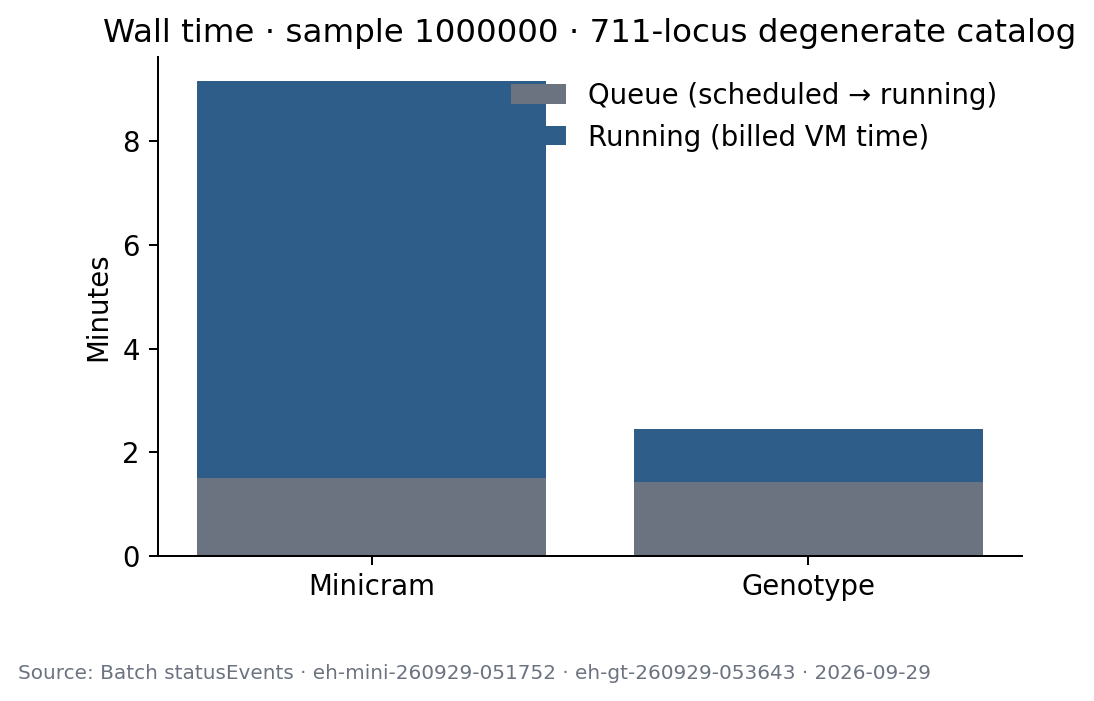

/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_smoke_711_walltime.pdf
/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_smoke_711_outputs.png


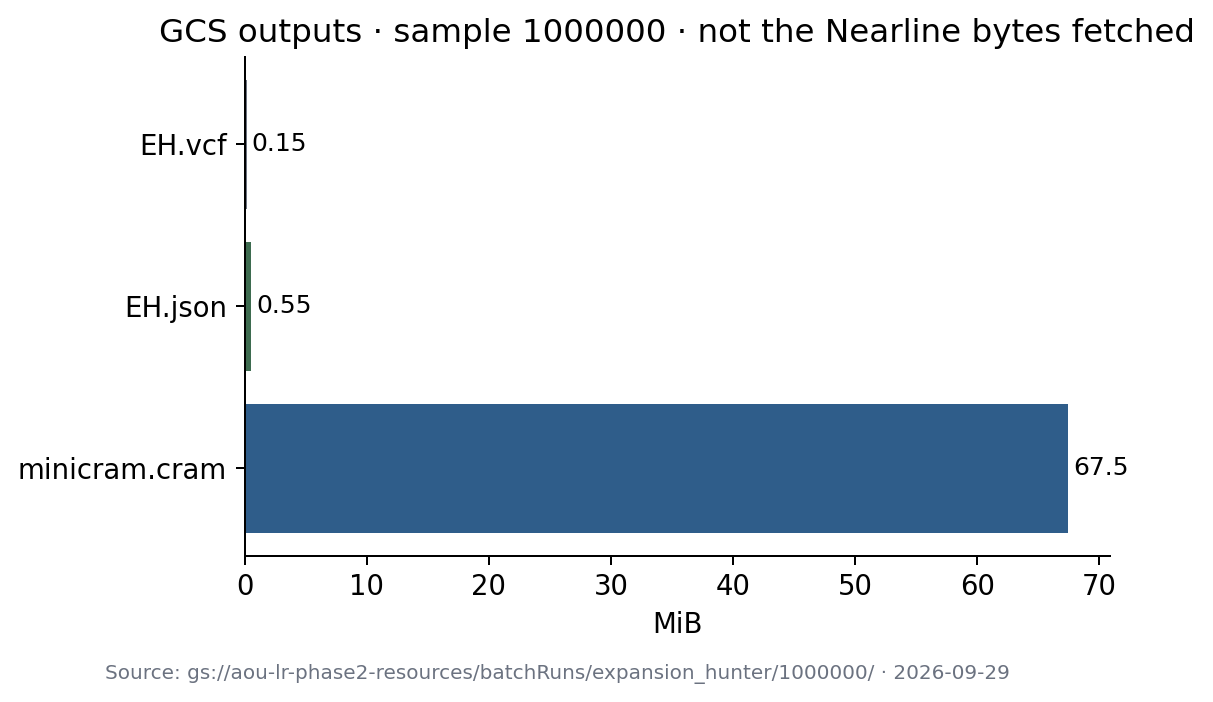

/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_smoke_711_outputs.pdf
/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_smoke_711_vm_cost.png


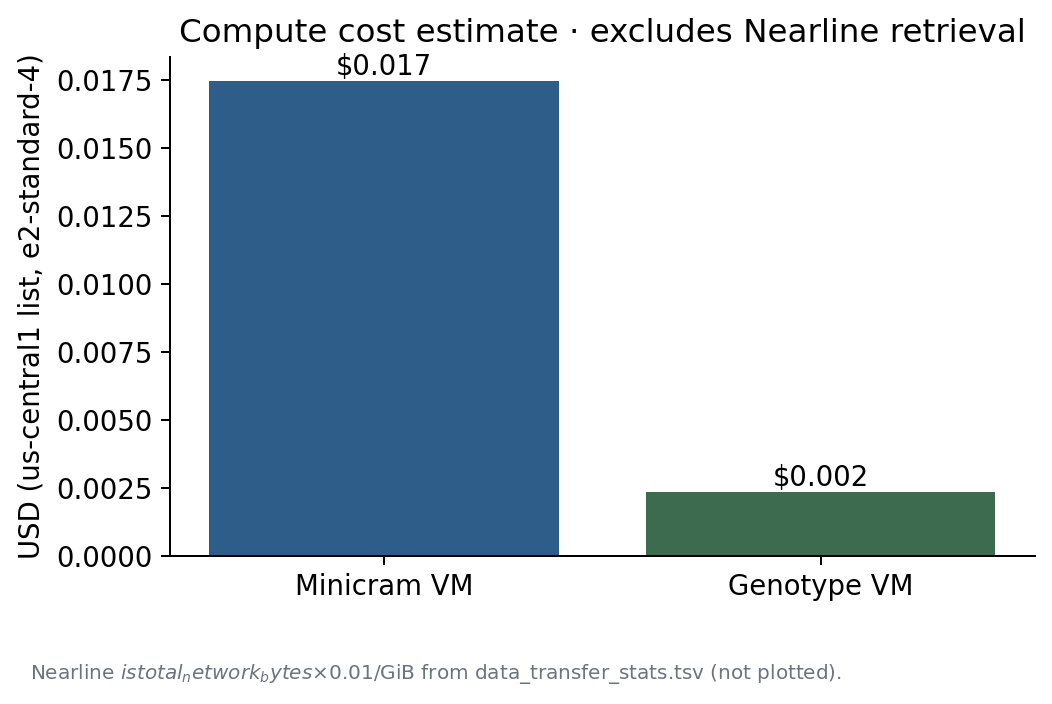

/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_smoke_711_vm_cost.pdf
/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_cost_hist.png


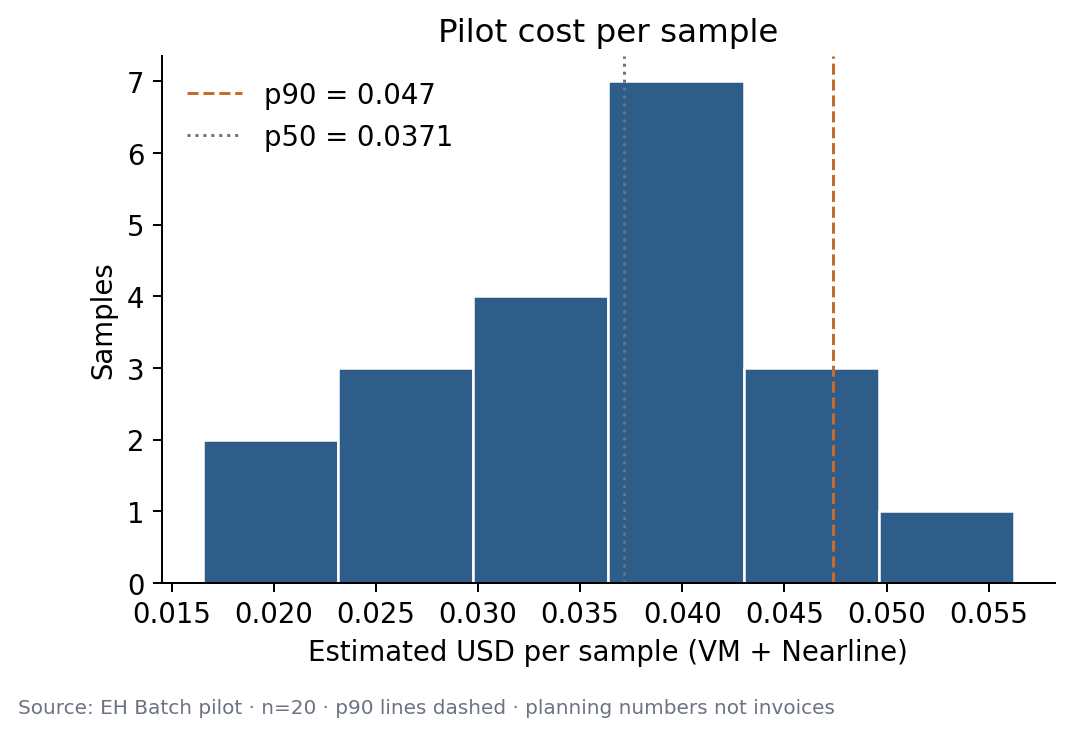

/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_cost_hist.pdf
/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_cost_stack.png


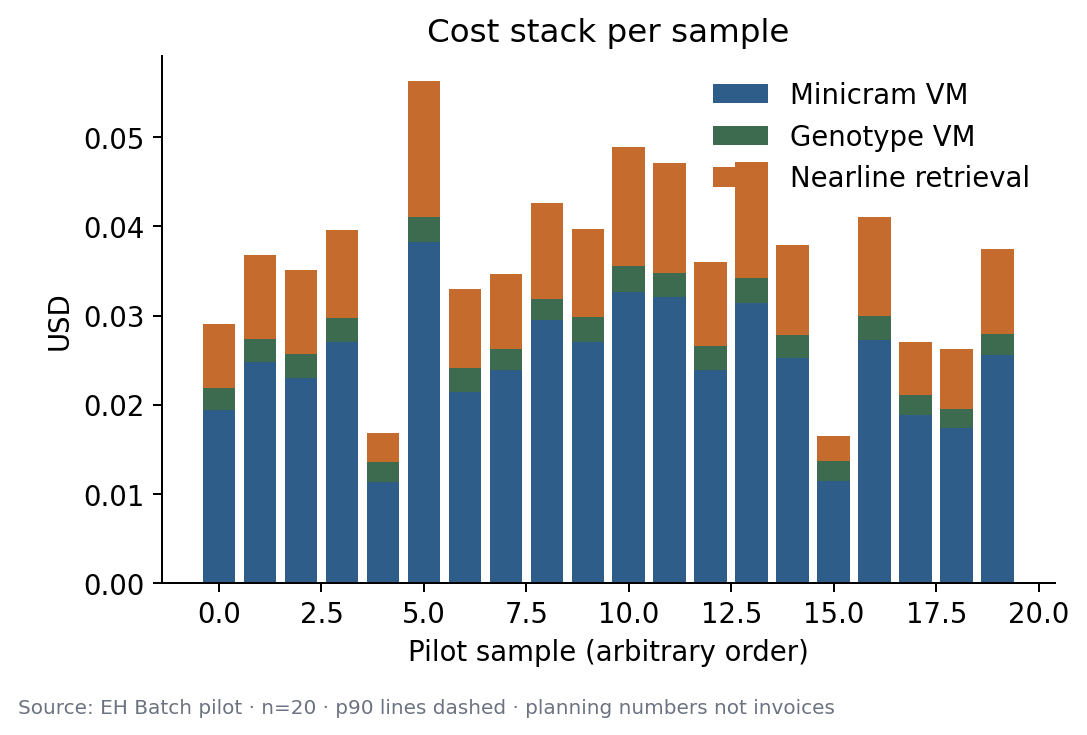

/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_cost_stack.pdf
/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_walltime.png


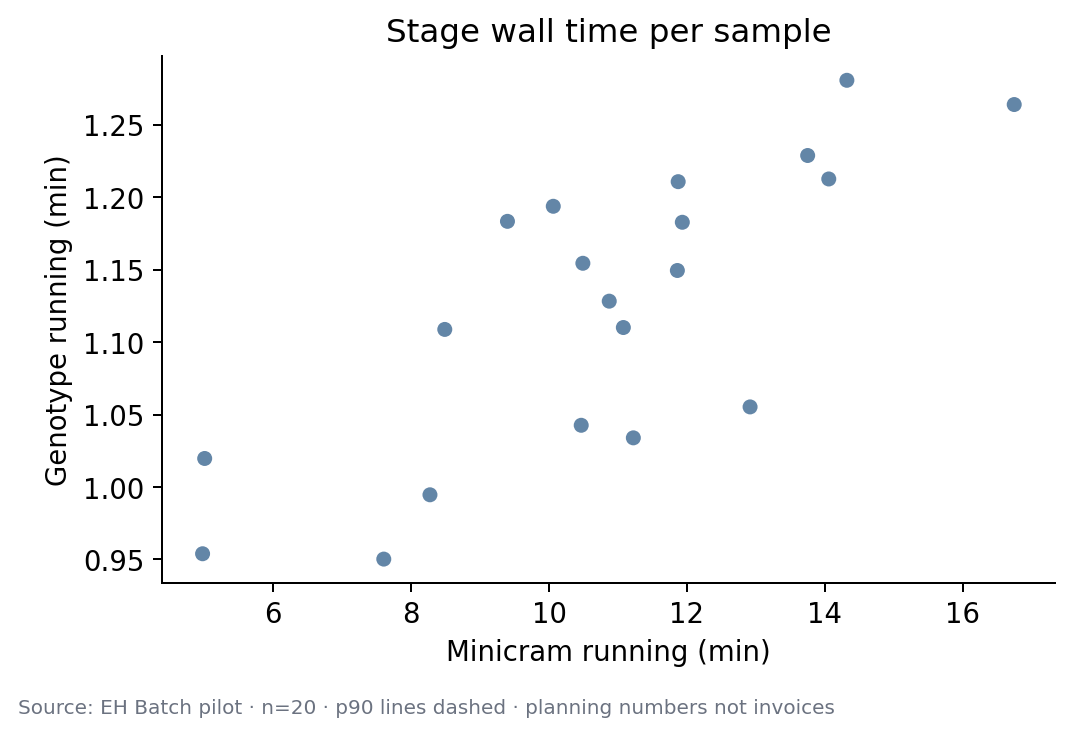

/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_walltime.pdf
/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_nearline.png


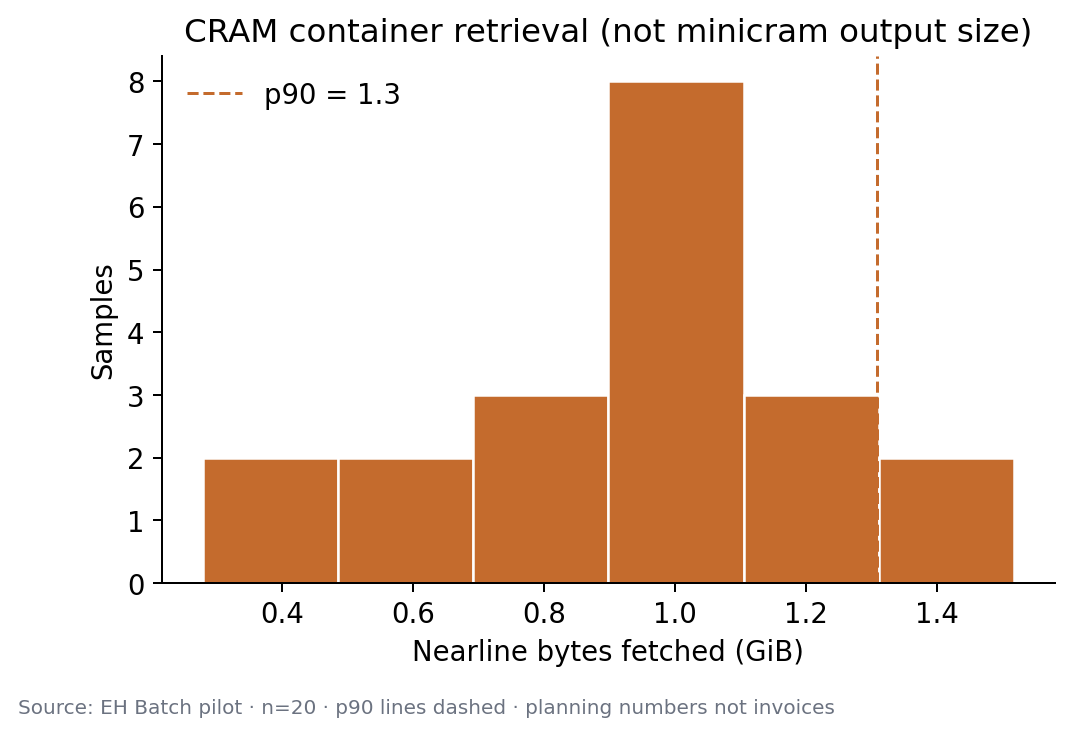

/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_nearline.pdf
/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_rss_minicram.png


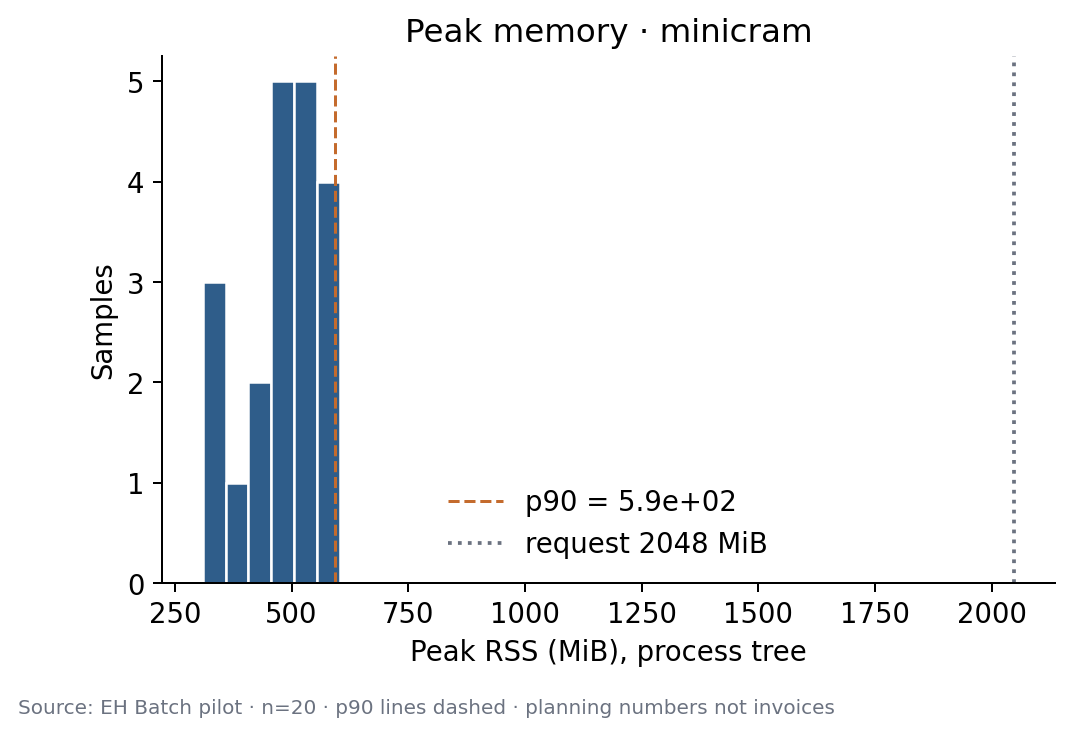

/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_rss_minicram.pdf
/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_cpu_minicram.png


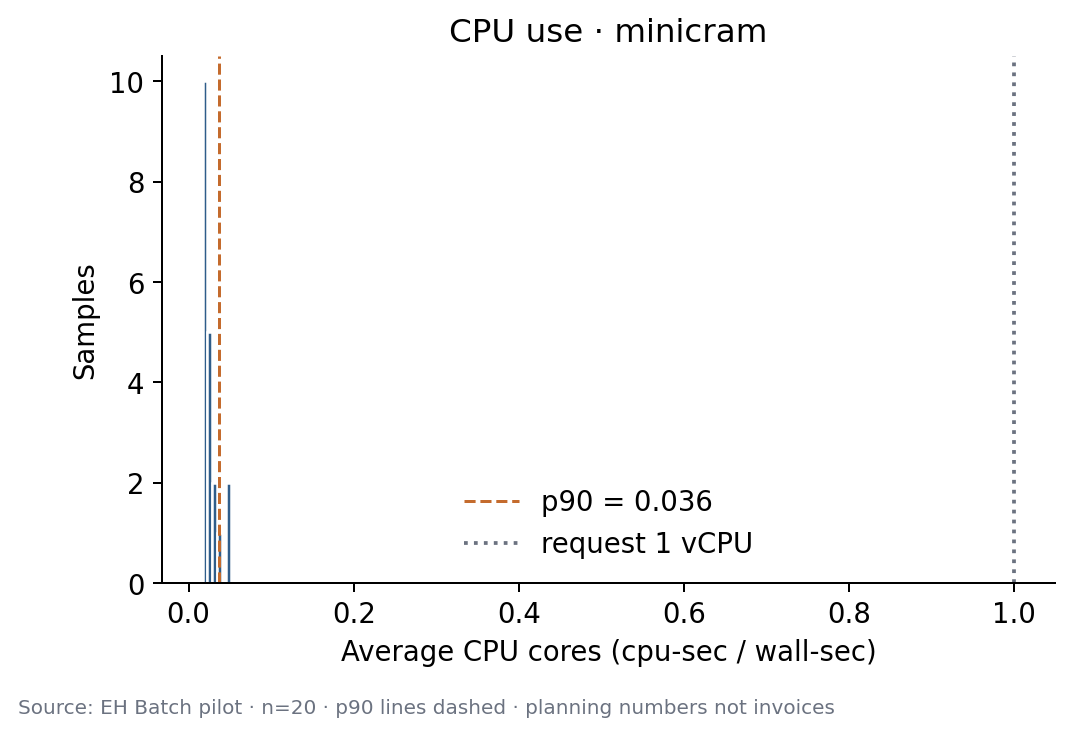

/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_cpu_minicram.pdf
/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_rss_genotype.png


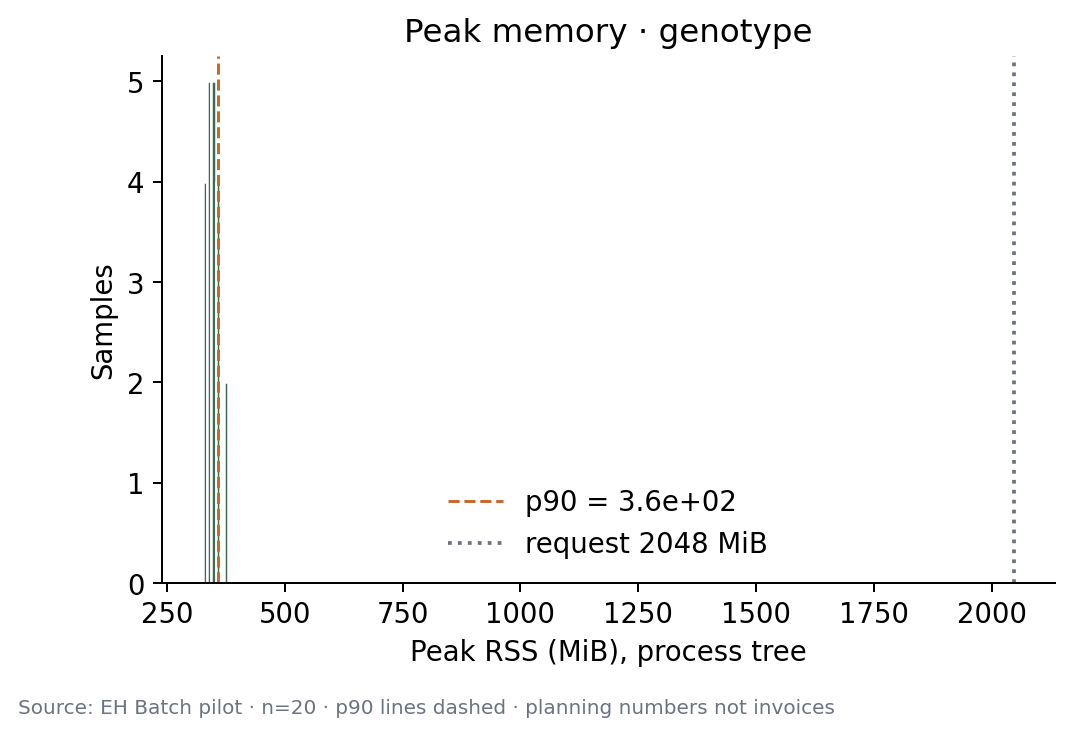

/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_rss_genotype.pdf
/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_cpu_genotype.png


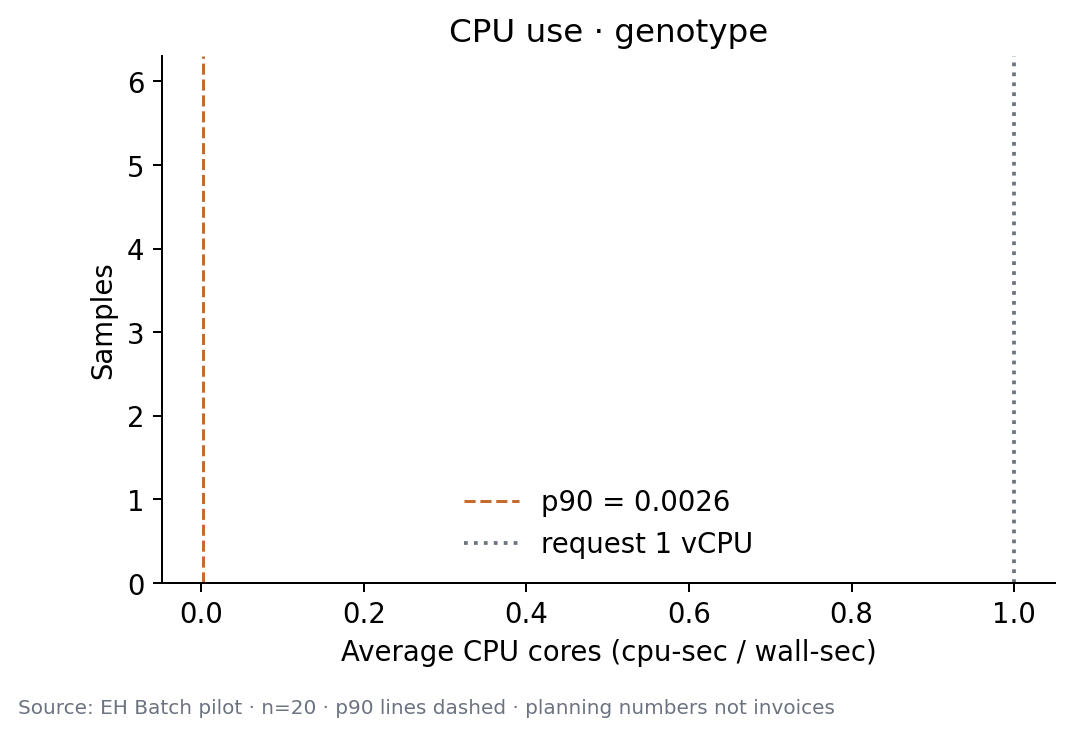

/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_cpu_genotype.pdf
/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_budget.png


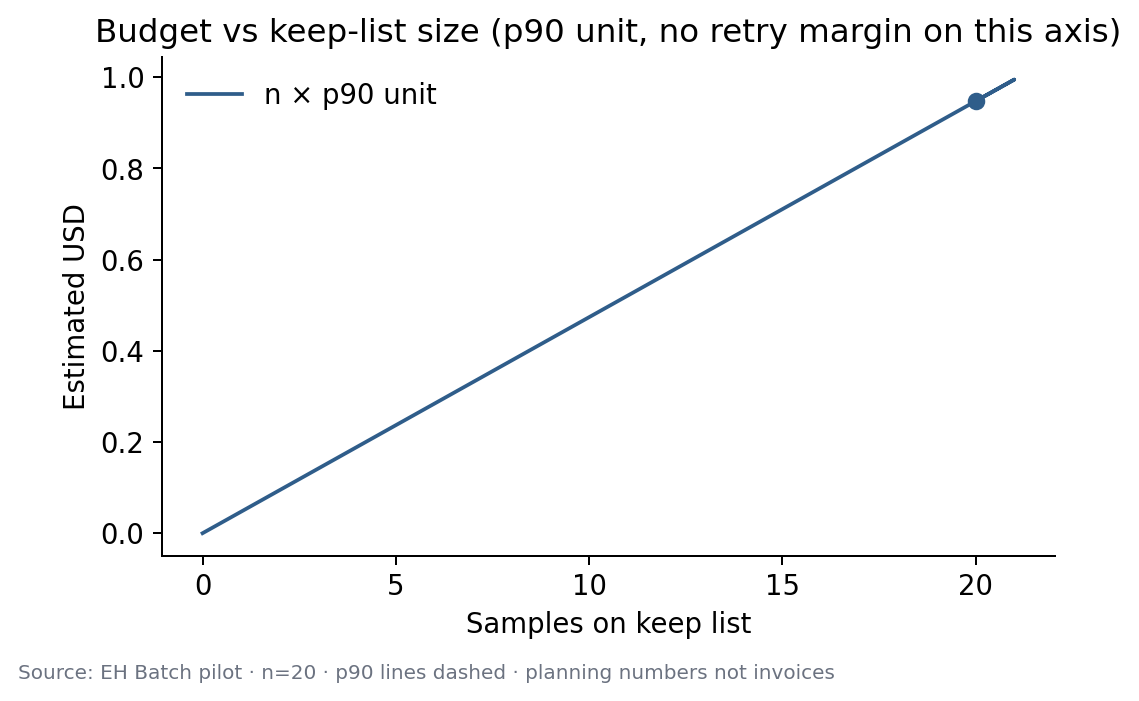

/home/jupyter/repos/aou-lr-phase-2/notebooks/rw/expansion_hunter_rw_scratch/eh-260929-pilot.figures/eh_pilot_budget.pdf
uploaded gs://aou-lr-phase2-resources/batchRuns/expansion_hunter/runs/eh-260929-pilot/figures/eh_smoke_711_walltime.png
uploaded gs://aou-lr-phase2-resources/batchRuns/expansion_hunter/runs/eh-260929-pilot/figures/eh_smoke_711_walltime.pdf
uploaded gs://aou-lr-phase2-resources/batchRuns/expansion_hunter/runs/eh-260929-pilot/figures/eh_smoke_711_outputs.png
uploaded gs://aou-lr-phase2-resources/batchRuns/expansion_hunter/runs/eh-260929-pilot/figures/eh_smoke_711_outputs.pdf
uploaded gs://aou-lr-phase2-resources/batchRuns/expansion_hunter/runs/eh-260929-pilot/figures/eh_smoke_711_vm_cost.png
uploaded gs://aou-lr-phase2-resources/batchRuns/expansion_hunter/runs/eh-260929-pilot/figures/eh_smoke_711_vm_cost.pdf
uploaded gs://aou-lr-phase2-resources/batchRuns/expansion_hunter/runs/eh-260929-pilot/figures/eh_pilot_cost_hist.png
uploaded gs://aou-lr-phase2-resources/batchRuns

In [23]:
from IPython.display import Image, display

from vwb_batch import plots  # noqa: E402

UPLOAD_FIGURES = True
FIG_DIR = SCRATCH / f"{RUN_ID}.figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

paths = plots.plot_smoke_711(FIG_DIR)

res_by_stage = {}
if "pilot_records" in dir() and "OUT_PREFIX" in dir():
    listing = set(gcs.ls_recursive(OUT_PREFIX.rstrip("/") + "/"))
    for stage in ("minicram", "genotype"):
        rows = []
        for rec in pilot_records:
            uri = eh.resource_stats_uri(rec["sample_id"], stage, OUT_PREFIX)
            if uri not in listing and not gcs.exists(uri):
                continue
            try:
                rows.append(cost.parse_resource_stats(gcs.cat(uri)))
            except Exception:
                continue
        res_by_stage[stage] = rows

cost_rows = costs if "costs" in dir() else []
keep_n = len(keep) if "keep" in dir() else 0
plan = summary["planning_usd"] if "summary" in dir() else 0.0
comp = compute_out if "compute_out" in dir() else {}
if cost_rows:
    paths += plots.plot_pilot(
        costs=cost_rows,
        resources=res_by_stage,
        compute=comp,
        out_dir=FIG_DIR,
        budget_usd=BUDGET_USD,
        n_keep=keep_n,
        planning_usd=plan,
    )
else:
    print("pilot cost table not in memory yet; smoke figures only")

for path in paths:
    print(path)
    if path.suffix == ".png":
        display(Image(filename=str(path), width=640))

if UPLOAD_FIGURES:
    for path in paths:
        dest = f"{PATHS.prefix}/figures/{path.name}"
        gcs.upload_file(path, dest)
        print("uploaded", dest)
